In [55]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import os
import importlib
import src.preprocessing as preprocessing_module
import src.data_splitter as data_splitter_module
import src.feature_engineering as feature_engineering_module
import src.handle_missing_value as missing_value_module

importlib.reload(preprocessing_module)
importlib.reload(data_splitter_module)
importlib.reload(feature_engineering_module)
importlib.reload(missing_value_module)

from src.preprocessing import TreeBasedPreprocessor
from src.data_splitter import DataSplitter, RespondentSimulationSplit, TrainValTestSplit
from src.feature_engineering import (
    FeatureEngineer, ValueFeatures, EngagementFeatures,
    ContractFeatures, TenureFeatures, DemographicFeatures,
    NPSLabelFeature  # ← ajout
)
from src.handle_missing_value import MissingValueHandler, CategoricalFillStrategy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from matplotlib.patches import Patch

import src.ingest_data
importlib.reload(src.ingest_data)
from src.ingest_data import DataIngestor, DataIngestorFactory

import config.ingestor_config
importlib.reload(config.ingestor_config)

import config.Paths
importlib.reload(config.Paths)
from config.Paths import ZIP_FILE



In [56]:
# check the file extension
file_path=ZIP_FILE
file_extension = os.path.splitext(file_path)[1]
from src.ingest_data import DataIngestorFactory

# 1. Créer l'ingestor
ingestor = DataIngestorFactory.get_data_ingestor(".zip")


df = ingestor.ingest(file_path)

print(df.shape)


(7043, 54)


In [57]:
# ── Étape 2 — Handle Missing Values ──
handler = MissingValueHandler(CategoricalFillStrategy(
    fill_map={
        "Offer"        : "No Offer",
        "Internet Type": "No Internet"
    }
))
df_clean = handler.handle_missing_values(df)
print("Valeurs manquantes restantes :")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

2026-05-04 00:35:38,944 - INFO - Executing missing value handling strategy.
2026-05-04 00:35:38,944 - INFO - Filling categorical missing values with map: {'Offer': 'No Offer', 'Internet Type': 'No Internet'}
2026-05-04 00:35:38,958 - INFO - Column 'Offer' — 3877 missing values filled with 'No Offer'.
2026-05-04 00:35:38,958 - INFO - Column 'Internet Type' — 1526 missing values filled with 'No Internet'.
2026-05-04 00:35:38,958 - INFO - Categorical missing values filled.


Valeurs manquantes restantes :
Churn Category    5174
Churn Reason      5174
dtype: int64


In [58]:
# ── Étape 3 — Feature Engineering ──
engineer = FeatureEngineer(strategies=[
    ValueFeatures(),
    EngagementFeatures(),
    ContractFeatures(),
    TenureFeatures(),
    DemographicFeatures(),
    NPSLabelFeature()  # crée NPS_Label (0=Detractor, 1=Passive, 2=Promoter)
])
df_enriched = engineer.run(df_clean)

print(f"Shape après feature engineering : {df_enriched.shape}")
print(f"Nouvelles colonnes : {[c for c in df_enriched.columns if c not in df_clean.columns]}")

2026-05-04 00:35:39,004 - INFO - Running 6 feature engineering strategies.
2026-05-04 00:35:39,006 - INFO - Creating value-based features.
2026-05-04 00:35:39,025 - INFO - Value-based features created.
2026-05-04 00:35:39,027 - INFO - Creating engagement-based features.
2026-05-04 00:35:40,394 - INFO - Engagement-based features created.
2026-05-04 00:35:40,394 - INFO - Creating contract-based features.
2026-05-04 00:35:40,400 - INFO - Contract-based features created.
2026-05-04 00:35:40,404 - INFO - Creating tenure-based features.
2026-05-04 00:35:40,408 - INFO - Tenure-based features created.
2026-05-04 00:35:40,408 - INFO - Creating demographic-based features.
2026-05-04 00:35:40,419 - INFO - Demographic-based features created.
2026-05-04 00:35:40,419 - INFO - Creating NPS label from Satisfaction Score.
2026-05-04 00:35:40,435 - INFO - NPS distribution :
NPS_Label
Detractor    0.583
Passive      0.254
Promoter     0.163
Name: proportion, dtype: float64
2026-05-04 00:35:40,435 - INFO 

Shape après feature engineering : (7043, 79)
Nouvelles colonnes : ['Revenue_Per_Month', 'Charge_Evolution', 'Refund_Rate', 'Has_Been_Refunded', 'Billing_Complexity', 'Services_Count', 'Streaming_Count', 'Security_Score', 'Full_Protection_Score', 'Support_Profile', 'Service_Diversity_Score', 'Referral_Rate', 'Heavy_Internet_User', 'Internet_Value', 'Contract_Encoded', 'Engagement_Score', 'Contract_Risk', 'Contract_Tenure_Mismatch', 'Locked_Value', 'Tenure_Segment', 'Vulnerable_Senior', 'Family_Profile', 'Digital_Profile', 'High_Value_At_Risk', 'NPS_Label']


In [59]:
# ── Étape 4 — Drop colonnes inutiles et données futures ──
template = TreeBasedPreprocessor()
df_ready = template.drop_from_full_df(df_enriched)

# Satisfaction Score doit rester pour NPS_Label — vérification
assert "NPS_Label" in df_ready.columns, "NPS_Label manquant !"
print(f"Shape après drop : {df_ready.shape}")

2026-05-04 00:35:40,460 - INFO - Dropping 16 columns: ['Customer ID', 'Count', 'Country', 'State', 'Lat Long', 'Quarter', 'ID', 'Churn Score', 'Churn Value', 'Churn Category', 'Churn Reason', 'Customer Status', 'CLTV', 'Zip Code', 'Latitude', 'Longitude']


Shape après drop : (7043, 63)


In [60]:
# ── Étape 5 — Simulation répondants / silencieux ──
# Stratifié sur NPS_Label
splitter = DataSplitter(RespondentSimulationSplit(response_rate=0.15))
df_respondents, df_silent = splitter.split(df_ready, "NPS_Label")

print(f"Répondants : {len(df_respondents)}")
print(f"Silencieux : {len(df_silent)}")

Path("../data/silent").mkdir(parents=True, exist_ok=True)
df_silent.to_csv("../data/silent/silent_customers.csv", index=False)
print("Silencieux sauvegardés → data/silent/silent_customers.csv")

2026-05-04 00:35:40,489 - INFO - Executing data splitting strategy.
2026-05-04 00:35:40,500 - INFO - Simulating 15.0% respondents stratified on 'NPS_Label'.
2026-05-04 00:35:40,522 - INFO - Dataset complet : 7043 clients
2026-05-04 00:35:40,522 - INFO - Répondants      : 1057 clients (15.0%)
2026-05-04 00:35:40,524 - INFO - Silencieux      : 5986 clients (85.0%)
2026-05-04 00:35:40,524 - INFO - Distribution répondants : {0: 0.583, 1: 0.254, 2: 0.163}
2026-05-04 00:35:40,524 - INFO - Distribution silencieux : {0: 0.583, 1: 0.254, 2: 0.163}


Répondants : 1057
Silencieux : 5986
Silencieux sauvegardés → data/silent/silent_customers.csv


In [61]:
# ── Étape 6 — Dériver C1 et C2 sur les répondants ──
df_respondents = df_respondents.copy()
df_respondents["NPS_C1"] = (df_respondents["NPS_Label"] == 0).astype(int)  # 1 = Detractor
df_respondents["NPS_C2"] = (df_respondents["NPS_Label"] == 2).astype(int)  # 1 = Promoter

print("Distribution NPS_C1 (Detractor) :")
print(df_respondents["NPS_C1"].value_counts(normalize=True).round(3))
print("\nDistribution NPS_C2 (Promoter) :")
print(df_respondents["NPS_C2"].value_counts(normalize=True).round(3))

Distribution NPS_C1 (Detractor) :
NPS_C1
1    0.583
0    0.417
Name: proportion, dtype: float64

Distribution NPS_C2 (Promoter) :
NPS_C2
0    0.837
1    0.163
Name: proportion, dtype: float64


In [62]:
# ── Étape 7 — Train / Val / Test — base commune ──
# On drop NPS_Label, NPS_C1, NPS_C2 pour avoir juste les features
df_base = df_respondents.drop(columns=["NPS_Label"])

splitter.set_strategy(TrainValTestSplit(test_size=0.15, val_size=0.15))

# Split sur C1 — les indices train/val/test seront les mêmes pour C2
X_train, X_val, X_test, y_train_c1, y_val_c1, y_test_c1 = splitter.split(
    df_base.drop(columns=["NPS_C2"]), "NPS_C1"
)

# Récupérer y_c2 sur les mêmes indices
y_train_c2 = df_respondents.loc[X_train.index, "NPS_C2"]
y_val_c2   = df_respondents.loc[X_val.index,   "NPS_C2"]
y_test_c2  = df_respondents.loc[X_test.index,  "NPS_C2"]

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")
print(f"Distribution C1 train : {y_train_c1.value_counts(normalize=True).round(3).to_dict()}")
print(f"Distribution C2 train : {y_train_c2.value_counts(normalize=True).round(3).to_dict()}")

2026-05-04 00:35:40,742 - INFO - Switching data splitting strategy.
2026-05-04 00:35:40,742 - INFO - Executing data splitting strategy.
2026-05-04 00:35:40,742 - INFO - Splitting test set (15.0%) stratified on 'NPS_C1'.
2026-05-04 00:35:40,760 - INFO - Splitting val set (15.0%) stratified on 'NPS_C1'.
2026-05-04 00:35:40,764 - INFO - Train      : 739 clients (69.9%)
2026-05-04 00:35:40,765 - INFO - Validation : 159 clients (15.0%)
2026-05-04 00:35:40,765 - INFO - Test       : 159 clients (15.0%)
2026-05-04 00:35:40,766 - INFO - Distribution Train      : {1: 0.582, 0: 0.418}
2026-05-04 00:35:40,768 - INFO - Distribution Validation : {1: 0.585, 0: 0.415}
2026-05-04 00:35:40,769 - INFO - Distribution Test       : {1: 0.585, 0: 0.415}


Train : (739, 62) | Val : (159, 62) | Test : (159, 62)
Distribution C1 train : {1: 0.582, 0: 0.418}
Distribution C2 train : {0: 0.831, 1: 0.169}


In [66]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# ── Étape 8 — Feature Importance C1 — 5-Fold CV — RF + XGBoost ──
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {
    "RandomForest": {"impurity": [], "permutation": []},
    "XGBoost"     : {"impurity": [], "permutation": []},
}

# Calcul du ratio pour scale_pos_weight XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"Déséquilibre C1 — Detractor: {pos} | Reste: {neg} | ratio: {scale:.2f}")

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        class_weight="balanced",   # ← gère le déséquilibre
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        scale_pos_weight=scale,    # ← gère le déséquilibre
        verbosity=0
    )
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_f, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_f, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

    _, preprocessor = template.preprocess(X_f)
    X_f_transformed = preprocessor.fit_transform(X_f)
    X_v_transformed = preprocessor.transform(X_v)

    feature_names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == "remainder":
            continue
        if hasattr(transformer, "get_feature_names_out"):
            feature_names.extend(transformer.get_feature_names_out(cols).tolist())
        else:
            feature_names.extend(cols)

    for model_name, model in models.items():
        model.fit(X_f_transformed, y_f)

        results[model_name]["impurity"].append(pd.Series(
            model.feature_importances_,
            index=feature_names
        ))

        # Permutation — scoring roc_auc ← beaucoup plus sensible
        perm = permutation_importance(
            model,
            X_v_transformed, y_v,
            n_repeats=10,
            random_state=42,
            n_jobs=-1,
            scoring="roc_auc"      # ← changement clé
        )
        results[model_name]["permutation"].append(pd.Series(
            perm.importances_mean,
            index=feature_names
        ))

        # Print roc_auc au lieu d'accuracy
        y_proba = model.predict_proba(X_v_transformed)[:, 1]
        auc = roc_auc_score(y_v, y_proba)
        print(f"Fold {fold} [{model_name}] — val ROC-AUC : {auc:.4f}")

2026-05-04 00:43:45,908 - INFO - Starting preprocessing pipeline.
2026-05-04 00:43:45,908 - INFO - Dropping 0 columns: []
2026-05-04 00:43:45,908 - INFO - [TreeBased] 20 numerical, 8 ordinal, 26 binary, 3 categorical cols.
2026-05-04 00:43:45,908 - INFO - Preprocessing pipeline ready.


Déséquilibre C1 — Detractor: 430 | Reste: 309 | ratio: 0.72
Fold 1 [RandomForest] — val ROC-AUC : 0.6463


2026-05-04 00:44:11,300 - INFO - Starting preprocessing pipeline.
2026-05-04 00:44:11,302 - INFO - Dropping 0 columns: []
2026-05-04 00:44:11,303 - INFO - [TreeBased] 20 numerical, 8 ordinal, 26 binary, 3 categorical cols.
2026-05-04 00:44:11,305 - INFO - Preprocessing pipeline ready.


Fold 1 [XGBoost] — val ROC-AUC : 0.6212
Fold 2 [RandomForest] — val ROC-AUC : 0.6679


2026-05-04 00:44:22,437 - INFO - Starting preprocessing pipeline.
2026-05-04 00:44:22,439 - INFO - Dropping 0 columns: []
2026-05-04 00:44:22,443 - INFO - [TreeBased] 20 numerical, 8 ordinal, 26 binary, 3 categorical cols.
2026-05-04 00:44:22,443 - INFO - Preprocessing pipeline ready.


Fold 2 [XGBoost] — val ROC-AUC : 0.6242
Fold 3 [RandomForest] — val ROC-AUC : 0.6414


2026-05-04 00:44:33,712 - INFO - Starting preprocessing pipeline.
2026-05-04 00:44:33,714 - INFO - Dropping 0 columns: []
2026-05-04 00:44:33,716 - INFO - [TreeBased] 20 numerical, 8 ordinal, 26 binary, 3 categorical cols.
2026-05-04 00:44:33,716 - INFO - Preprocessing pipeline ready.


Fold 3 [XGBoost] — val ROC-AUC : 0.6088
Fold 4 [RandomForest] — val ROC-AUC : 0.6755


2026-05-04 00:44:45,329 - INFO - Starting preprocessing pipeline.
2026-05-04 00:44:45,331 - INFO - Dropping 0 columns: []
2026-05-04 00:44:45,333 - INFO - [TreeBased] 20 numerical, 8 ordinal, 26 binary, 3 categorical cols.
2026-05-04 00:44:45,335 - INFO - Preprocessing pipeline ready.


Fold 4 [XGBoost] — val ROC-AUC : 0.6200
Fold 5 [RandomForest] — val ROC-AUC : 0.6224
Fold 5 [XGBoost] — val ROC-AUC : 0.6291


Features consensus (RF + XGBoost impurity) : 7
['Avg Monthly GB Download', 'Engagement_Score', 'Internet_Value', 'Locked_Value', 'Monthly Charge', 'Number of Referrals', 'Online Security']


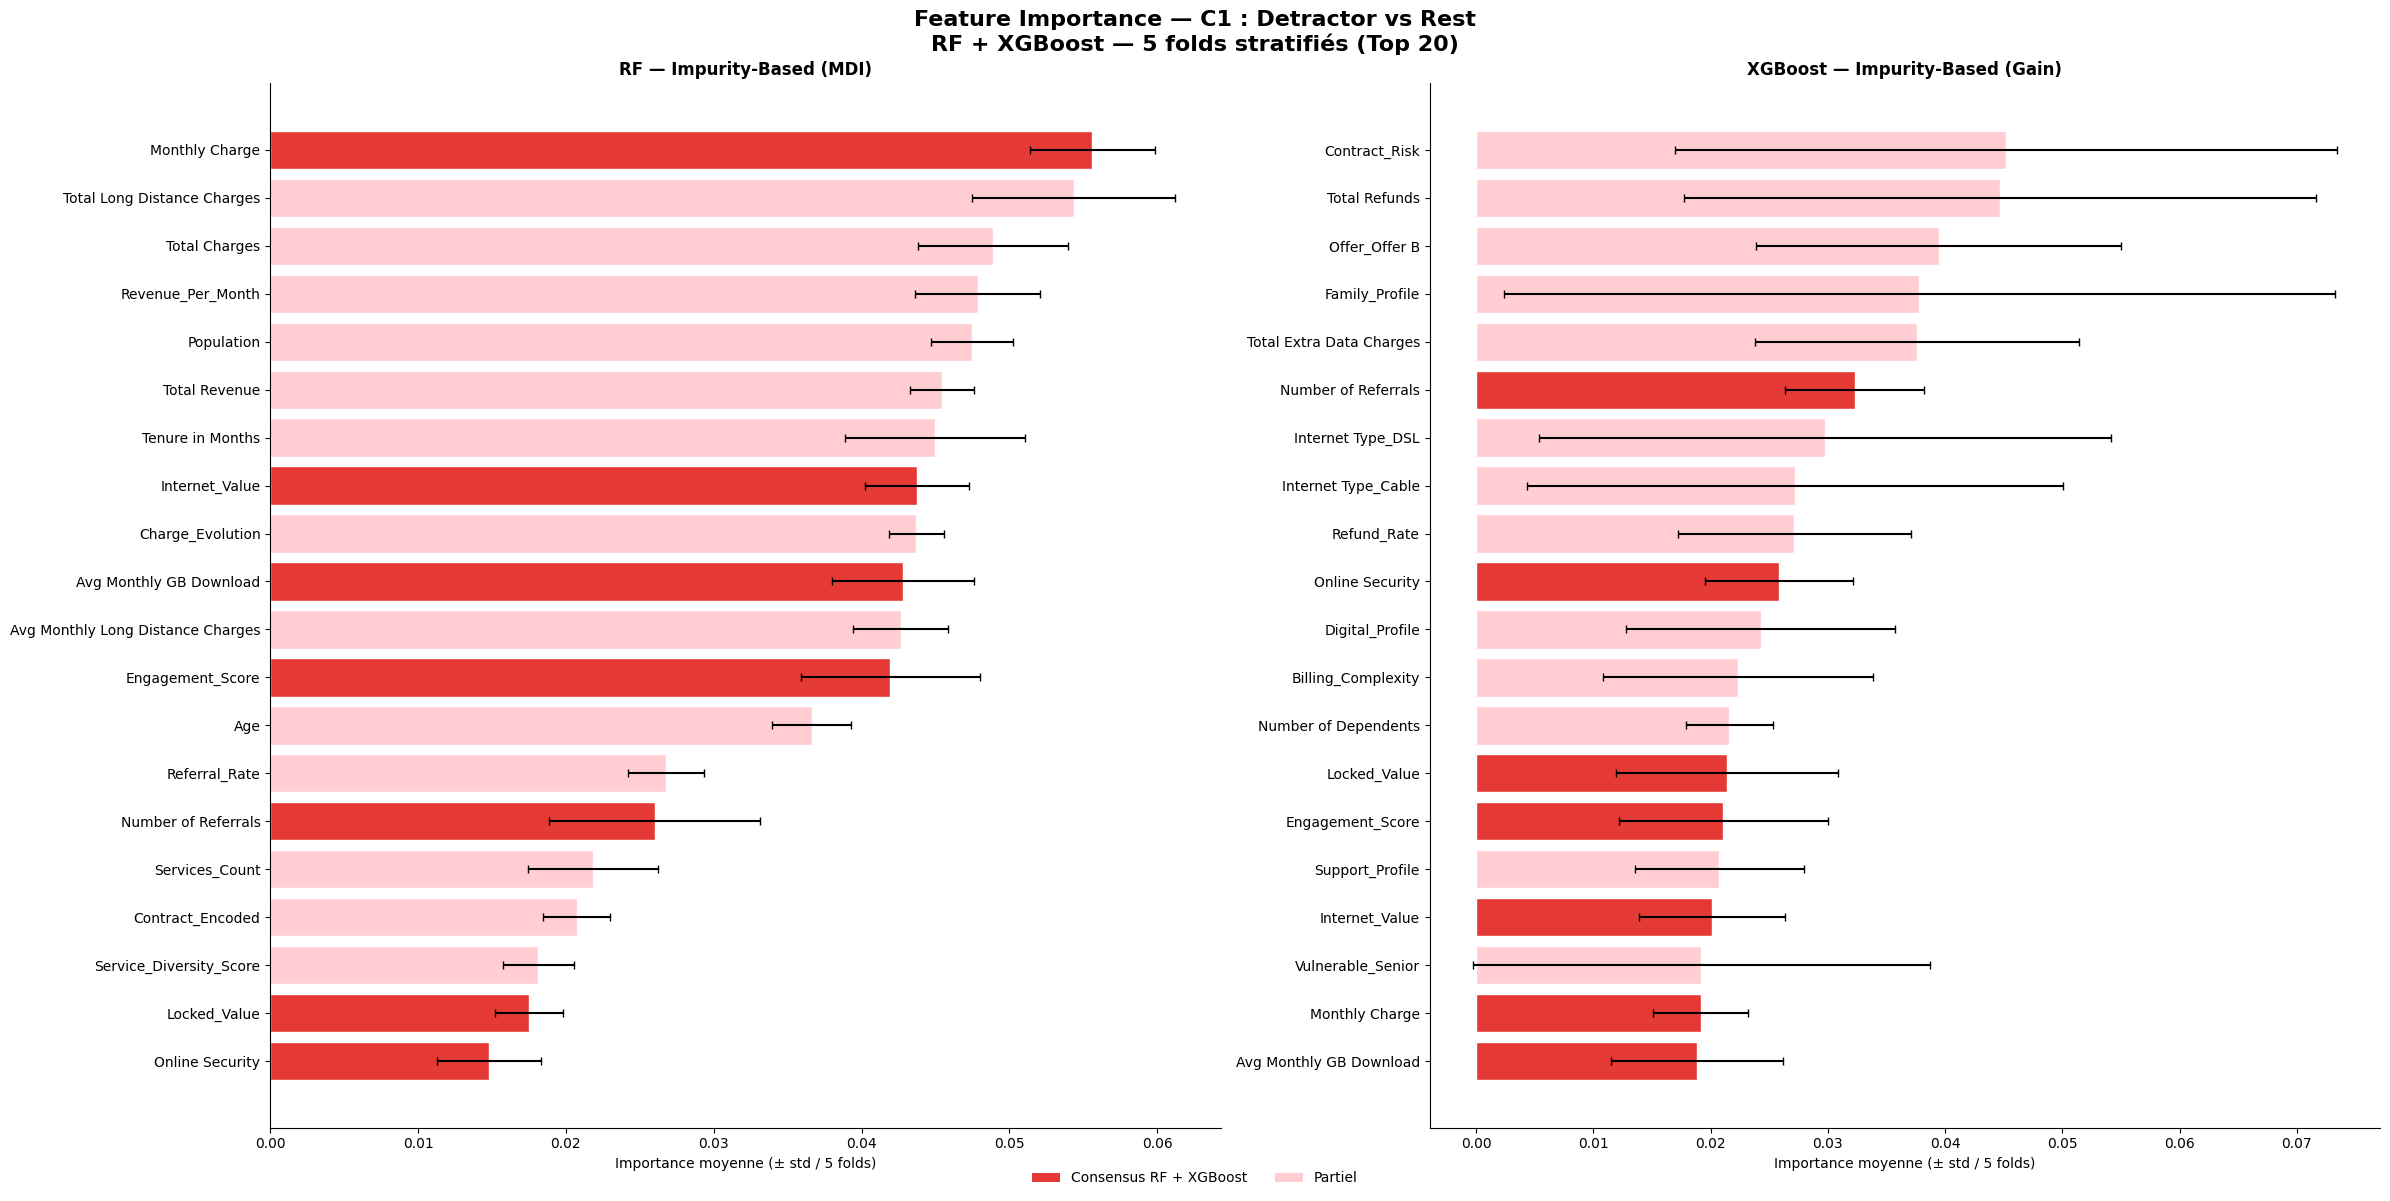


=== Features consensus C1 — Detractor ===
                         rf_impurity_rank  xgb_impurity_rank  \
Monthly Charge                          1                 19   
Internet_Value                          8                 17   
Avg Monthly GB Download                10                 20   
Engagement_Score                       12                 15   
Number of Referrals                    15                  6   
Locked_Value                           19                 14   
Online Security                        20                 10   

                         rf_impurity_score  xgb_impurity_score  
Monthly Charge                    0.055607            0.019138  
Internet_Value                    0.043756            0.020127  
Avg Monthly GB Download           0.042785            0.018804  
Engagement_Score                  0.041946            0.021094  
Number of Referrals               0.025997            0.032286  
Locked_Value                      0.017528            

In [65]:
# ── Étape 9 — Agrégation ──
TOP_N = 20

agg = {}
for model_name in results:
    agg[model_name] = {
        "impurity_mean"    : pd.DataFrame(results[model_name]["impurity"]).mean().sort_values(ascending=False),
        "impurity_std"     : pd.DataFrame(results[model_name]["impurity"]).std(),
        "permutation_mean" : pd.DataFrame(results[model_name]["permutation"]).mean().sort_values(ascending=False),
        "permutation_std"  : pd.DataFrame(results[model_name]["permutation"]).std(),
    }

# Features consensus — présentes dans les 2 top impurity
top_rf_imp  = set(agg["RandomForest"]["impurity_mean"].head(TOP_N).index)
top_xgb_imp = set(agg["XGBoost"]["impurity_mean"].head(TOP_N).index)

consensus = top_rf_imp & top_xgb_imp
print(f"Features consensus (RF + XGBoost impurity) : {len(consensus)}")
print(sorted(consensus))

# ── Étape 10 — Visualisation — 1x2 (Impurity seulement) ──
fig, axes = plt.subplots(1, 2, figsize=(24, 12))
fig.suptitle(
    "Feature Importance — C1 : Detractor vs Rest\n"
    "RF + XGBoost — 5 folds stratifiés (Top 20)",
    fontsize=16, fontweight="bold"
)

configs = [
    (axes[0], "RandomForest", "impurity", "RF — Impurity-Based (MDI)",       "#E53935", "#FFCDD2"),
    (axes[1], "XGBoost",      "impurity", "XGBoost — Impurity-Based (Gain)", "#E53935", "#FFCDD2"),
]

for ax, model_name, metric, title, base_color, light_color in configs:
    top    = agg[model_name][f"{metric}_mean"].head(TOP_N)
    std    = agg[model_name][f"{metric}_std"]
    colors = [base_color if f in consensus else light_color for f in top.index]

    ax.barh(
        top.index[::-1], top.values[::-1],
        xerr=std[top.index[::-1]].values,
        color=colors[::-1], edgecolor="white", capsize=3
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance moyenne (± std / 5 folds)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

fig.legend(handles=[
    Patch(facecolor="#E53935", label="Consensus RF + XGBoost"),
    Patch(facecolor="#FFCDD2", label="Partiel"),
], loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig("../docs/feature_importance_C1_detractor.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Étape 11 — Tableau consensus ──
consensus_df = pd.DataFrame({
    "rf_impurity_rank"  : {f: list(agg["RandomForest"]["impurity_mean"].index).index(f)+1 for f in consensus},
    "xgb_impurity_rank" : {f: list(agg["XGBoost"]["impurity_mean"].index).index(f)+1      for f in consensus},
    "rf_impurity_score" : agg["RandomForest"]["impurity_mean"][list(consensus)],
    "xgb_impurity_score": agg["XGBoost"]["impurity_mean"][list(consensus)],
}).sort_values("rf_impurity_rank")

print("\n=== Features consensus C1 — Detractor ===")
print(consensus_df)

In [67]:
# ── Étape 6 — Filtrer Passifs + Dériver C1 ──
df_respondents = df_respondents.copy()

# Supprimer les Passifs (NPS_Label == 1)
df_respondents = df_respondents[df_respondents["NPS_Label"] != 1].copy()

print(f"Après suppression Passifs : {len(df_respondents)} clients")
print(f"\nDistribution NPS_Label :")
print(df_respondents["NPS_Label"].value_counts())

# C1 : Detractor=1 vs Promoter=0
df_respondents["NPS_C1"] = (df_respondents["NPS_Label"] == 0).astype(int)

print(f"\nDistribution NPS_C1 :")
print(df_respondents["NPS_C1"].value_counts(normalize=True).round(3))

Après suppression Passifs : 788 clients

Distribution NPS_Label :
NPS_Label
0    616
2    172
Name: count, dtype: int64

Distribution NPS_C1 :
NPS_C1
1    0.782
0    0.218
Name: proportion, dtype: float64


In [68]:
# ── Étape 7 — Train / Val / Test ──
df_c1 = df_respondents.drop(columns=["NPS_Label"])

splitter.set_strategy(TrainValTestSplit(test_size=0.15, val_size=0.15))
X_train, X_val, X_test, y_train, y_val, y_test = splitter.split(df_c1, "NPS_C1")

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")
print(f"\nDistribution y_train : {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Distribution y_val   : {y_val.value_counts(normalize=True).round(3).to_dict()}")
print(f"Distribution y_test  : {y_test.value_counts(normalize=True).round(3).to_dict()}")

2026-05-04 11:07:23,013 - INFO - Switching data splitting strategy.
2026-05-04 11:07:23,015 - INFO - Executing data splitting strategy.
2026-05-04 11:07:23,019 - INFO - Splitting test set (15.0%) stratified on 'NPS_C1'.
2026-05-04 11:07:23,042 - INFO - Splitting val set (15.0%) stratified on 'NPS_C1'.
2026-05-04 11:07:23,042 - INFO - Train      : 550 clients (69.8%)
2026-05-04 11:07:23,042 - INFO - Validation : 119 clients (15.1%)
2026-05-04 11:07:23,042 - INFO - Test       : 119 clients (15.1%)
2026-05-04 11:07:23,042 - INFO - Distribution Train      : {1: 0.782, 0: 0.218}
2026-05-04 11:07:23,042 - INFO - Distribution Validation : {1: 0.782, 0: 0.218}
2026-05-04 11:07:23,042 - INFO - Distribution Test       : {1: 0.782, 0: 0.218}


Train : (550, 63) | Val : (119, 63) | Test : (119, 63)

Distribution y_train : {1: 0.782, 0: 0.218}
Distribution y_val   : {1: 0.782, 0: 0.218}
Distribution y_test  : {1: 0.782, 0: 0.218}


In [69]:
# ── Étape 8 — Feature Importance C1 — 5-Fold CV — RF + XGBoost ──
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {
    "RandomForest": {"impurity": [], "permutation": []},
    "XGBoost"     : {"impurity": [], "permutation": []},
}

neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = neg / pos
print(f"Detractor : {pos} | Promoter : {neg} | ratio : {scale:.2f}")

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        scale_pos_weight=scale,
        verbosity=0
    )
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_f, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_f, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

    _, preprocessor = template.preprocess(X_f)
    X_f_transformed = preprocessor.fit_transform(X_f)
    X_v_transformed = preprocessor.transform(X_v)

    feature_names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == "remainder":
            continue
        if hasattr(transformer, "get_feature_names_out"):
            feature_names.extend(transformer.get_feature_names_out(cols).tolist())
        else:
            feature_names.extend(cols)

    for model_name, model in models.items():
        model.fit(X_f_transformed, y_f)

        results[model_name]["impurity"].append(pd.Series(
            model.feature_importances_,
            index=feature_names
        ))

        perm = permutation_importance(
            model,
            X_v_transformed, y_v,
            n_repeats=10,
            random_state=42,
            n_jobs=-1,
            scoring="roc_auc"
        )
        results[model_name]["permutation"].append(pd.Series(
            perm.importances_mean,
            index=feature_names
        ))

        y_proba = model.predict_proba(X_v_transformed)[:, 1]
        auc = roc_auc_score(y_v, y_proba)
        print(f"Fold {fold} [{model_name}] — val ROC-AUC : {auc:.4f}")

2026-05-04 11:07:23,147 - INFO - Starting preprocessing pipeline.
2026-05-04 11:07:23,149 - INFO - Dropping 0 columns: []
2026-05-04 11:07:23,151 - INFO - [TreeBased] 20 numerical, 8 ordinal, 26 binary, 3 categorical cols.
2026-05-04 11:07:23,151 - INFO - Preprocessing pipeline ready.


Detractor : 430 | Promoter : 120 | ratio : 0.28
Fold 1 [RandomForest] — val ROC-AUC : 0.7485


2026-05-04 11:07:47,875 - INFO - Starting preprocessing pipeline.
2026-05-04 11:07:47,877 - INFO - Dropping 0 columns: []
2026-05-04 11:07:47,881 - INFO - [TreeBased] 20 numerical, 8 ordinal, 26 binary, 3 categorical cols.
2026-05-04 11:07:47,881 - INFO - Preprocessing pipeline ready.


Fold 1 [XGBoost] — val ROC-AUC : 0.7408
Fold 2 [RandomForest] — val ROC-AUC : 0.7587


2026-05-04 11:07:59,083 - INFO - Starting preprocessing pipeline.
2026-05-04 11:07:59,083 - INFO - Dropping 0 columns: []
2026-05-04 11:07:59,085 - INFO - [TreeBased] 20 numerical, 8 ordinal, 26 binary, 3 categorical cols.
2026-05-04 11:07:59,087 - INFO - Preprocessing pipeline ready.


Fold 2 [XGBoost] — val ROC-AUC : 0.7466
Fold 3 [RandomForest] — val ROC-AUC : 0.7355


2026-05-04 11:08:11,011 - INFO - Starting preprocessing pipeline.
2026-05-04 11:08:11,013 - INFO - Dropping 0 columns: []
2026-05-04 11:08:11,015 - INFO - [TreeBased] 20 numerical, 8 ordinal, 26 binary, 3 categorical cols.
2026-05-04 11:08:11,017 - INFO - Preprocessing pipeline ready.


Fold 3 [XGBoost] — val ROC-AUC : 0.7016
Fold 4 [RandomForest] — val ROC-AUC : 0.7655


2026-05-04 11:08:22,896 - INFO - Starting preprocessing pipeline.
2026-05-04 11:08:22,898 - INFO - Dropping 0 columns: []
2026-05-04 11:08:22,900 - INFO - [TreeBased] 20 numerical, 8 ordinal, 26 binary, 3 categorical cols.
2026-05-04 11:08:22,901 - INFO - Preprocessing pipeline ready.


Fold 4 [XGBoost] — val ROC-AUC : 0.7442
Fold 5 [RandomForest] — val ROC-AUC : 0.7398
Fold 5 [XGBoost] — val ROC-AUC : 0.7403


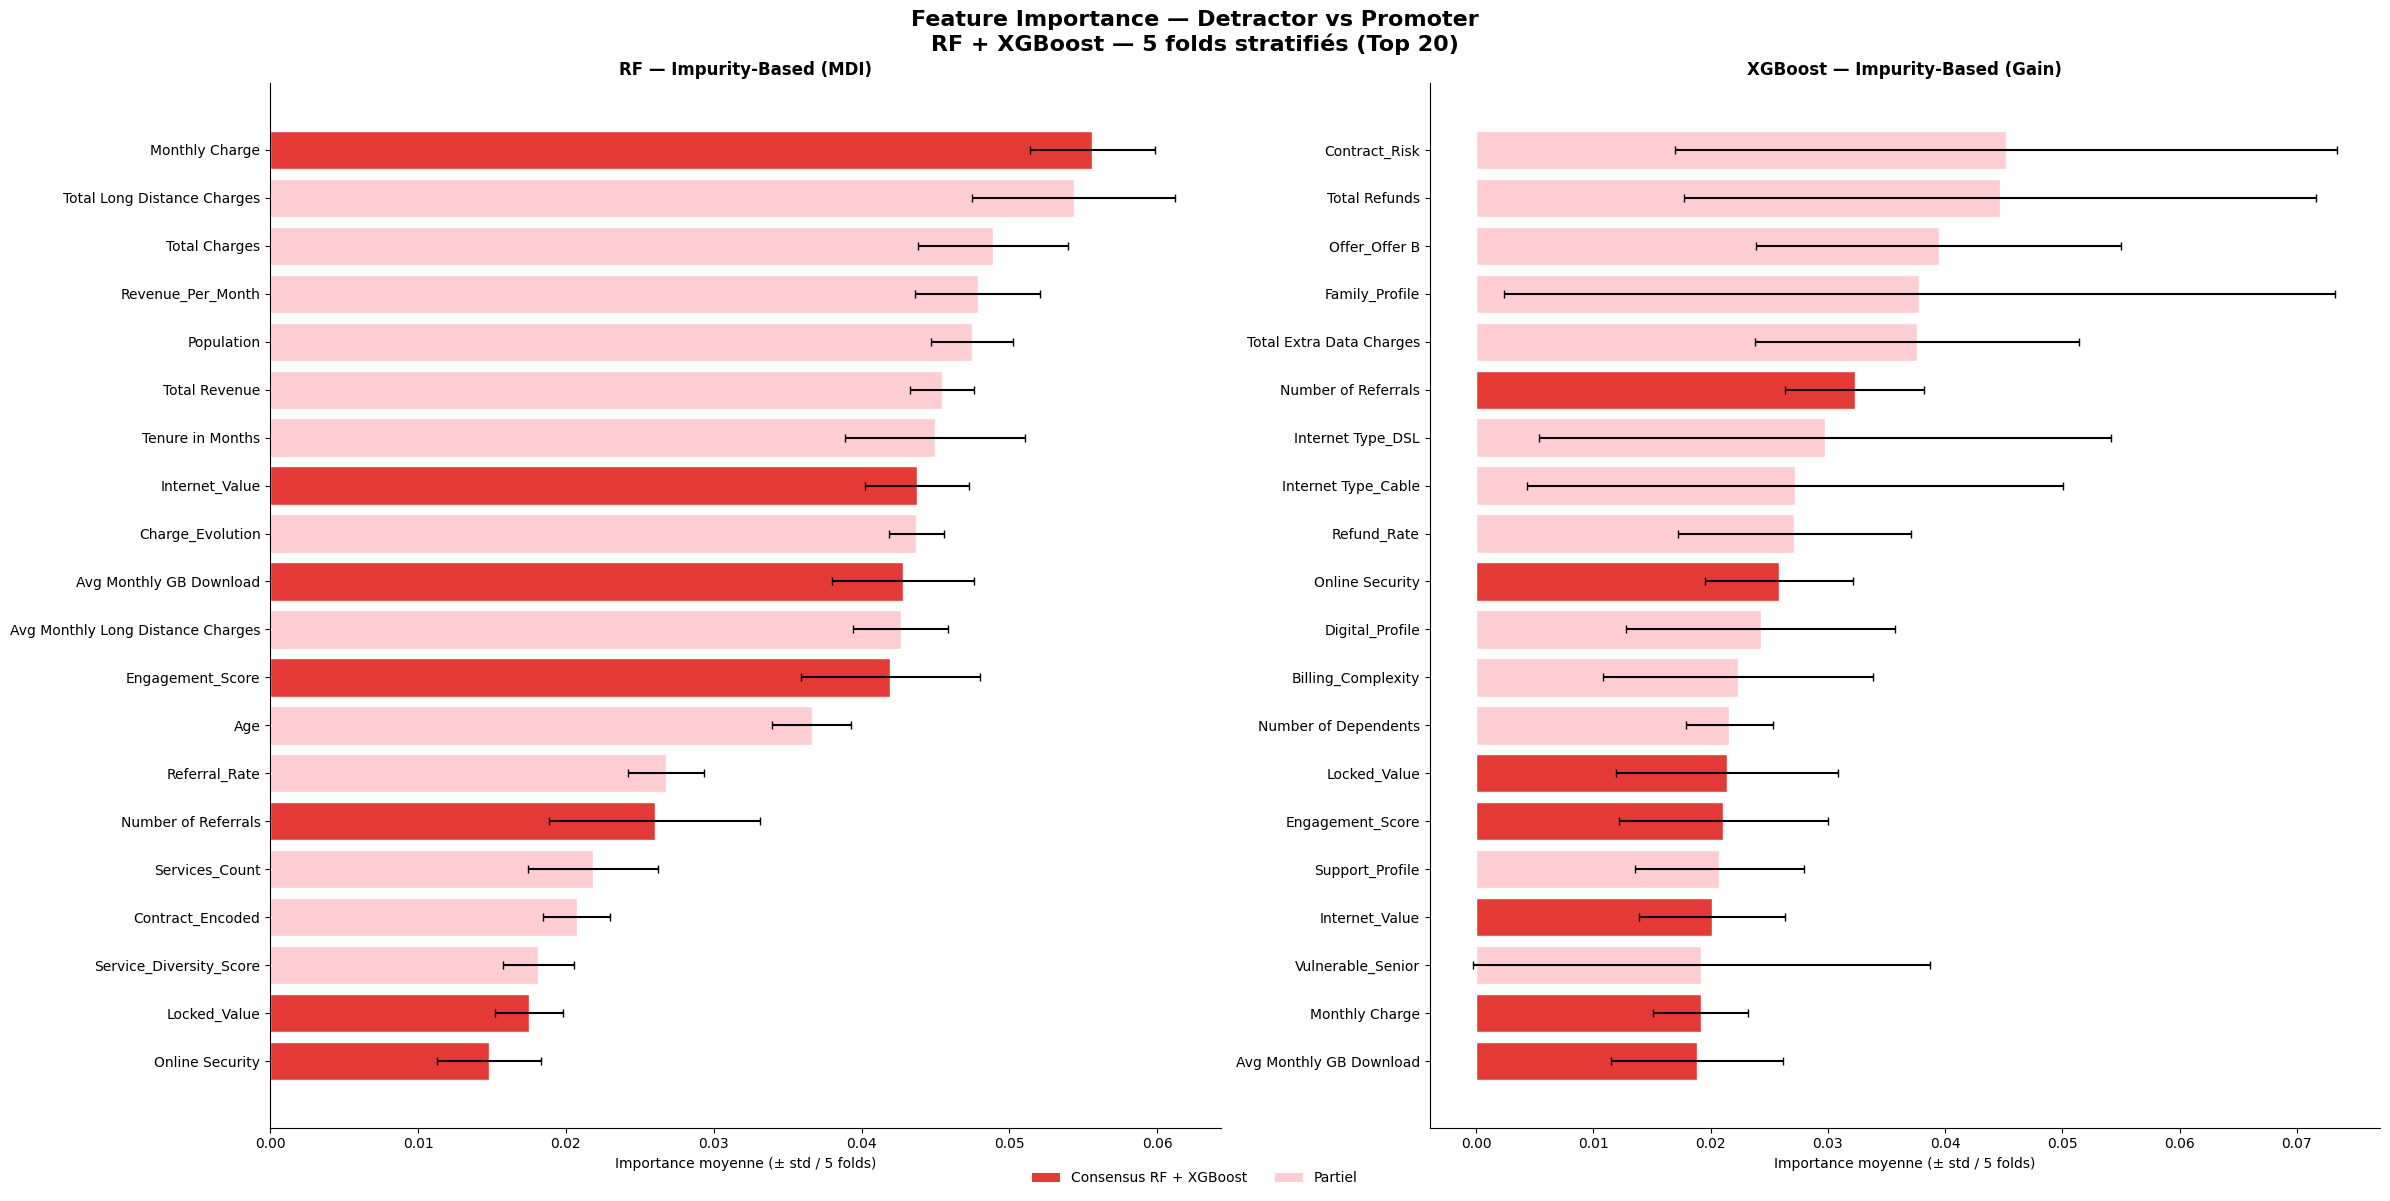

In [70]:
# ── Étape 10 — Visualisation 1x2 ──
fig, axes = plt.subplots(1, 2, figsize=(24, 12))
fig.suptitle(
    "Feature Importance — Detractor vs Promoter\n"
    "RF + XGBoost — 5 folds stratifiés (Top 20)",
    fontsize=16, fontweight="bold"
)

configs = [
    (axes[0], "RandomForest", "impurity", "RF — Impurity-Based (MDI)",       "#E53935", "#FFCDD2"),
    (axes[1], "XGBoost",      "impurity", "XGBoost — Impurity-Based (Gain)", "#E53935", "#FFCDD2"),
]

for ax, model_name, metric, title, base_color, light_color in configs:
    top    = agg[model_name][f"{metric}_mean"].head(TOP_N)
    std    = agg[model_name][f"{metric}_std"]
    colors = [base_color if f in consensus else light_color for f in top.index]

    ax.barh(
        top.index[::-1], top.values[::-1],
        xerr=std[top.index[::-1]].values,
        color=colors[::-1], edgecolor="white", capsize=3
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance moyenne (± std / 5 folds)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

fig.legend(handles=[
    Patch(facecolor="#E53935", label="Consensus RF + XGBoost"),
    Patch(facecolor="#FFCDD2", label="Partiel"),
], loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig("../docs/feature_importance_C1_detractor_vs_promoter.png", dpi=150, bbox_inches="tight")
plt.show()